In [70]:
# Import necessary libraries

import os
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from fpdf import FPDF
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import lasio
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import argparse
import warnings
warnings.filterwarnings("ignore")



In [71]:
# LAS file paths
Well_1 = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 1.las"
Well_2 = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 2.las"
Well_3 = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 3.las"
Well_4 = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 4.las"

# Map well names to file paths
las_files = {
    "Well 1": Well_1,
    "Well 2": Well_2,
    "Well 3": Well_3,
    "Well 4": Well_4,
}

# Features for the autoencoder
features = ['DEPT', 'GR', 'RHOB', 'DT', 'ILD', 'SP', 'CALD', 'DRHO']


In [72]:
# Load the Data 
Df1 = lasio.read(Well_1)
df1 = Df1.df().reset_index()
df1.columns = df1.columns.str.upper()
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df1.columns]
missing = [col for col in features if col not in df1.columns]
print(f"Missing features in Well 1: {missing}")
Df2 = lasio.read(Well_2)
df2 = Df2.df().reset_index()
df2.columns = df2.columns.str.upper()
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df2.columns]
missing = [col for col in features if col not in df2.columns]
print(f"Missing features in Well 2: {missing}")
Df3 = lasio.read(Well_3)
df3 = Df3.df().reset_index()
df3.columns = df3.columns.str.upper()
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df3.columns]
missing = [col for col in features if col not in df3.columns]
print(f"Missing features in Well 3: {missing}")
Df4 = lasio.read(Well_4)
df4 = Df4.df().reset_index()
df4.columns = df4.columns.str.upper()
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df4.columns]
missing = [col for col in features if col not in df4.columns]
print(f"Missing features in Well 4: {missing}")

# Data Cleaning
def clean_data(df, features):
    df = df[features]
    imputer = SimpleImputer(strategy='mean')
    df[features] = imputer.fit_transform(df[features])
    return df
df1 = clean_data(df1, features)
df2 = clean_data(df2, features)
df3 = clean_data(df3, features)
df4 = clean_data(df4, features)

# Head of the cleaned data
print("Head of cleaned data for Well 1:")
print(df1.head())
print("Head of cleaned data for Well 2:")
print(df2.head())
print("Head of cleaned data for Well 3:")
print(df3.head())
print("Head of cleaned data for Well 4:")
print(df4.head())


# Preprocessing Function
def preprocess_data(df, features):
    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features])
    return df, scaler   
df1, scaler1 = preprocess_data(df1, features)
df2, scaler2 = preprocess_data(df2, features)
df3, scaler3 = preprocess_data(df3, features)
df4, scaler4 = preprocess_data(df4, features)
# Data Summary of processed data
print("Data summary for Well 1:")
print(df1.info())
print("Data summary for Well 2:")
print(df2.info())
print("Data summary for Well 3:")
print(df3.info())
print("Data summary for Well 4:")
print(df4.info())

# Data Cleaning Summary
df1_selected = df1[features]
df1_clean = clean_data(df1_selected, features)
print(f"Well 1: Original Rows = {len(df1_selected)}, Cleaned Rows = {len(df1_clean)}")
df2_selected = df2[features]
df2_clean = clean_data(df2_selected, features)
print(f"Well 2: Original Rows = {len(df2_selected)}, Cleaned Rows = {len(df2_clean)}")
df3_selected = df3[features]    
df3_clean = clean_data(df3_selected, features)
print(f"Well 3: Original Rows = {len(df3_selected)}, Cleaned Rows = {len(df3_clean)}")
df4_selected = df4[features]    
df4_clean = clean_data(df4_selected, features)
print(f"Well 4: Original Rows = {len(df4_selected)}, Cleaned Rows = {len(df4_clean)}")
print("\n")


Missing features in Well 1: []
Missing features in Well 2: []
Missing features in Well 3: []
Missing features in Well 4: []
Head of cleaned data for Well 1:
     DEPT      GR        DT      RHOB        ILD        SP   CALD      DRHO
0  3180.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
1  3180.5  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
2  3181.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3  3181.5  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
4  3182.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
Head of cleaned data for Well 2:
    DEPT         GR         DT      RHOB        ILD         SP      CALD  \
0  152.5  76.404279  91.409715  2.479543  26.984755 -21.746874  8.005198   
1  153.0  76.404279  91.409715  2.479543  26.984755 -21.746874  8.005198   
2  153.5  76.404279  91.409715  2.479543  26.984755 -21.746874  8.005198   
3  154.0  76.404279  91.409715  2.479543  26.98475

In [87]:
# Load the LAS file
from matplotlib import scale


Df1 = lasio.read(Well_1)
df = Df1.df().reset_index()   
df.columns = df.columns.str.upper()  
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df.columns]
missing = [col for col in features if col not in df.columns]

df1_selected = df[available].copy()
if missing:
    print(f"Warning: The following expected features are missing from the data and will be ignored: {missing}") 
print(f"Using features: {available}")

Df2 = lasio.read(Well_2)
df2 = Df2.df().reset_index()  
df2.columns = df2.columns.str.upper() 
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df2.columns]
missing = [col for col in features if col not in df2.columns]

df2_selected = df2[available].copy()
if missing:
    print(f"Warning: The following expected features are missing from the data and will be ignored: {missing}")
print(f"Using features: {available}")

Df3 = lasio.read(Well_3)
df3 = Df3.df().reset_index()   
df3.columns = df3.columns.str.upper() 
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df3.columns]
missing = [col for col in features if col not in df3.columns]
df3_selected = df3[available].copy()
if missing:
    print(f"Warning: The following expected features are missing from the data and will be ignored: {missing}")
print(f"Using features: {available}")

Df4 = lasio.read(Well_4)    
df4 = Df4.df().reset_index()   
df4.columns = df4.columns.str.upper()  
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df4.columns]
missing = [col for col in features if col not in df4.columns]
df4_selected = df4[available].copy()
if missing:
    print(f"Warning: The following expected features are missing from the data and will be ignored: {missing}")
print(f"Using features: {available}")


# Data Cleaning Function
def preprocess_data(df):
    # Remove rows with NaN values
    df = df.dropna()
    # Reset index
    df = df.reset_index(drop=True)
    return df

# Preprocess each well's data
df1_clean = preprocess_data(df1_selected)
df2_clean = preprocess_data(df2_selected)
df3_clean = preprocess_data(df3_selected)
df4_clean = preprocess_data(df4_selected)


# Data Cleaning Summary
print("=== Data Cleaning Summary ===")
print(f"Well 1: Original Rows = {len(df1_selected)}, Cleaned Rows = {len(df1_clean)}")
print(f"Well 2: Original Rows = {len(df2_selected)}, Cleaned Rows = {len(df2_clean)}")
print(f"Well 3: Original Rows = {len(df3_selected)}, Cleaned Rows = {len(df3_clean)}")
print(f"Well 4: Original Rows = {len(df4_selected)}, Cleaned Rows = {len(df4_clean)}")
print("\n")

# View the first few rows of each cleaned well
print("=== Well 1 (After Preprocessing) ===")
print(df1_clean.head(), "\n")

print("=== Well 2 (After Preprocessing) ===")
print(df2_clean.head(), "\n")

print("=== Well 3 (After Preprocessing) ===")
print(df3_clean.head(), "\n")

print("=== Well 4 (After Preprocessing) ===")
print(df4_clean.head(), "\n")

# Standardize  and Scale the data
scale
scaler = StandardScaler()
# Standardize the data
df1_scaled = pd.DataFrame(scaler.fit_transform(df1_clean.drop(columns=['DEPT'])), columns=df1_clean.columns.drop('DEPT'))   
df1_scaled['DEPT'] = df1_clean['DEPT'].values 
df1_scaled = df1_scaled[['DEPT'] + df1_clean.columns.drop('DEPT').tolist()] 
df1_scaled['Well'] = 'Well 1'
df1_scaled = df1_scaled.reset_index(drop=True)
df2_scaled = pd.DataFrame(scaler.fit_transform(df2_clean.drop(columns=['DEPT'])), columns=df2_clean.columns.drop('DEPT'))
df2_scaled['DEPT'] = df2_clean['DEPT'].values       
df2_scaled = df2_scaled[['DEPT'] + df2_clean.columns.drop('DEPT').tolist()]
df2_scaled['Well'] = 'Well 2'
df2_scaled = df2_scaled.reset_index(drop=True)      
df3_scaled = pd.DataFrame(scaler.fit_transform(df3_clean.drop(columns=['DEPT'])), columns=df3_clean.columns.drop('DEPT'))
df3_scaled['DEPT'] = df3_clean['DEPT'].values   
df3_scaled = df3_scaled[['DEPT'] + df3_clean.columns.drop('DEPT').tolist()]
df3_scaled['Well'] = 'Well 3'
df3_scaled = df3_scaled.reset_index(drop=True)
df4_scaled = pd.DataFrame(scaler.fit_transform(df4_clean.drop(columns=['DEPT'])), columns=df4_clean.columns.drop('DEPT'))
df4_scaled['DEPT'] = df4_clean['DEPT'].values   
df4_scaled = df4_scaled[['DEPT'] + df4_clean.columns.drop('DEPT').tolist()]
df4_scaled['Well'] = 'Well 4'   
df4_scaled = df4_scaled.reset_index(drop=True)  
# Summary of Scaling before and after
print("=== Summary of Scaling ===")
print("Well 1: Mean (before) = {:.4f}, Std (before) = {:.4f}".format(df1_clean.drop(columns=['DEPT']).mean().mean(), df1_clean.drop(columns=['DEPT']).std().mean()))
print("Well 1: Mean (after) = {:.4f}, Std (after) = {:.4f}".format(df1_scaled.drop(columns=['DEPT', 'Well']).mean().mean(), df1_scaled.drop(columns=['DEPT', 'Well']).std().mean()))
# Head of the scaled data
print("=== Head of Scaled Data for Well 1 ===")
print(df1_scaled.head())

# Alternative Scaling Approach
scaler = MinMaxScaler()









Using features: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
=== Data Cleaning Summary ===
Well 1: Original Rows = 567, Cleaned Rows = 302
Well 2: Original Rows = 6622, Cleaned Rows = 6353
Well 3: Original Rows = 567, Cleaned Rows = 302
Well 4: Original Rows = 565, Cleaned Rows = 460


=== Well 1 (After Preprocessing) ===
     DEPT     GR     DT  RHOB    ILD     SP  CALD  DRHO
0  3246.5  38.63  59.33  2.65  35.28 -10.94   7.8  0.01
1  3247.0  41.06  59.56  2.65  35.89 -11.23   7.8  0.01
2  3247.5  43.04  59.91  2.67  36.56 -11.70   7.8  0.02
3  3248.0  41.43  60.06  2.68  37.59 -12.28   7.8  0.02
4  3248.5  38.64  59.91  2.67  38.53 -12.80   7.8  0.02 

=== Well 2 (After Preprocessing) ===
    DEPT     GR      DT  RHOB       ILD    SP  CALD  DRHO
0  219.5

In [74]:
# === Step 1: Prepare data per well and keep track of indices ===
well_indices = {}
X_list = []
start_idx = 0

for well_name, df in wells.items():
    # Use only the features that exist in this well
    available_features = [f for f in features if f in df.columns]
    X_well = df[available_features].values
    X_list.append(X_well)
    
    end_idx = start_idx + X_well.shape[0]
    well_indices[well_name] = (start_idx, end_idx, available_features)
    start_idx = end_idx

# Concatenate for training
X = np.vstack(X_list)

# === Step 2: Train autoencoder (same as before) ===
input_dim = X.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=Adam(), loss='mse')

autoencoder.fit(X, X, epochs=50, batch_size=32, validation_split=0.1, shuffle=True)

# === Step 3: Detect anomalies ===
reconstructed = autoencoder.predict(X)
mse = np.mean(np.power(X - reconstructed, 2), axis=1)
threshold = np.mean(mse) + 2 * np.std(mse)
anomalies = mse > threshold

# === Step 4: Map anomalies back to each well ===
well_anomaly_data = {}
for well_name, (start, end, available_features) in well_indices.items():
    df_copy = wells[well_name].copy()
    # Only assign anomalies for the rows corresponding to features
    df_copy['ANOMALY'] = ['Anomaly' if a else 'Normal' for a in anomalies[start:end]]
    well_anomaly_data[well_name] = df_copy

# === Step 5: Plot with legend ===
import matplotlib.patches as mpatches

for well_name, df in well_anomaly_data.items():
    for feature in features:
        if feature not in df.columns:
            continue
        plt.figure(figsize=(6, 8))
        colors = df['ANOMALY'].map({'Normal':'blue','Anomaly':'red'})
        plt.scatter(df[feature], df['DEPT'], c=colors, s=10)
        plt.gca().invert_yaxis()
        plt.title(f"{feature} vs Depth ({well_name})")
        plt.xlabel(feature)
        plt.ylabel("Depth (m)")
        normal_patch = mpatches.Patch(color='blue', label='Normal')
        anomaly_patch = mpatches.Patch(color='red', label='Anomaly')
        plt.legend(handles=[normal_patch, anomaly_patch])
        plt.show()

# Summary of anomalies per well
for well_name, df in well_anomaly_data.items():
    anomaly_count = df['ANOMALY'].value_counts().get('Anomaly', 0)
    total_count = df.shape[0]
    print(f"{well_name}: {anomaly_count} anomalies out of {total_count} samples ({(anomaly_count/total_count)*100:.2f}%)")

ValueError: need at least one array to concatenate

Well 1 saved to Well_1_cleaned.csv
Well 2 saved to Well_2_cleaned.csv
Well 3 saved to Well_3_cleaned.csv
Well 4 saved to Well_4_cleaned.csv
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


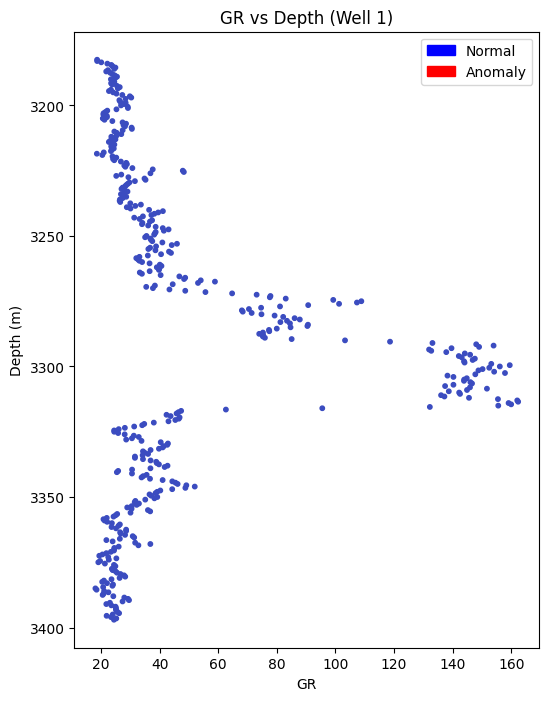

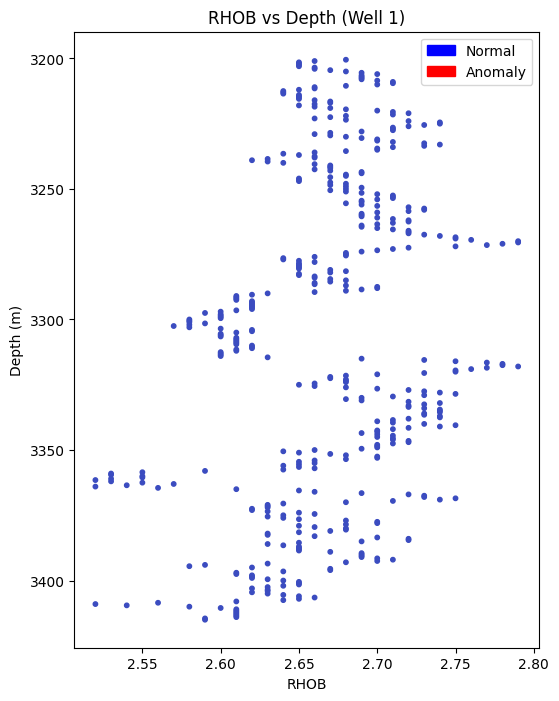

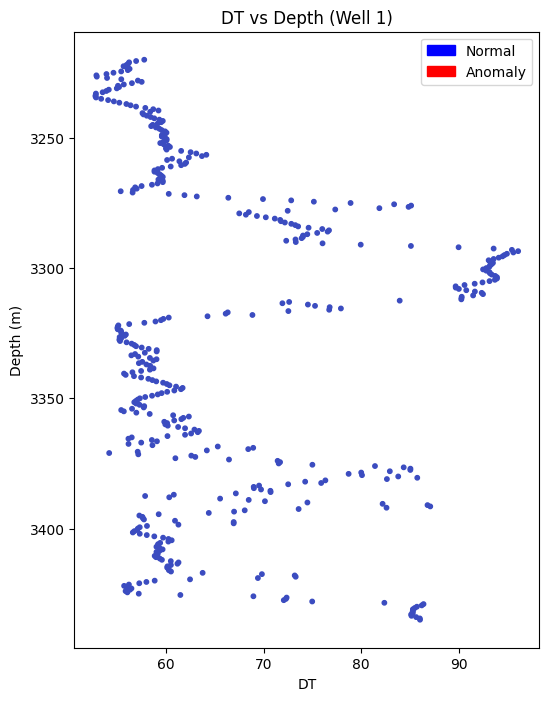

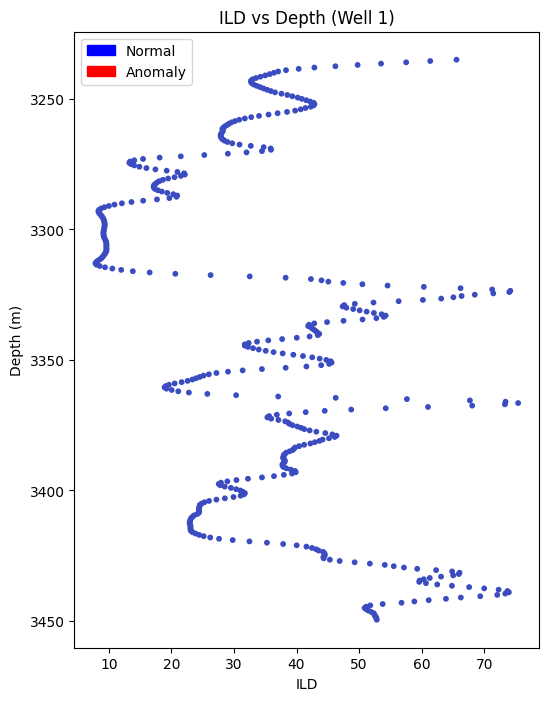

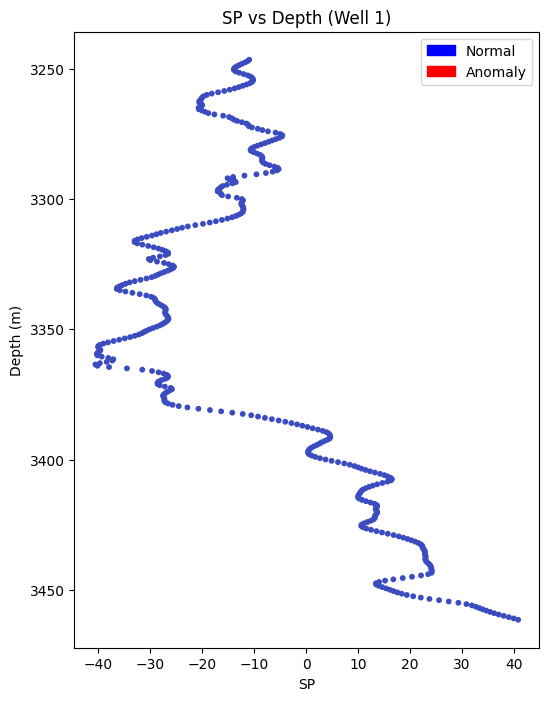

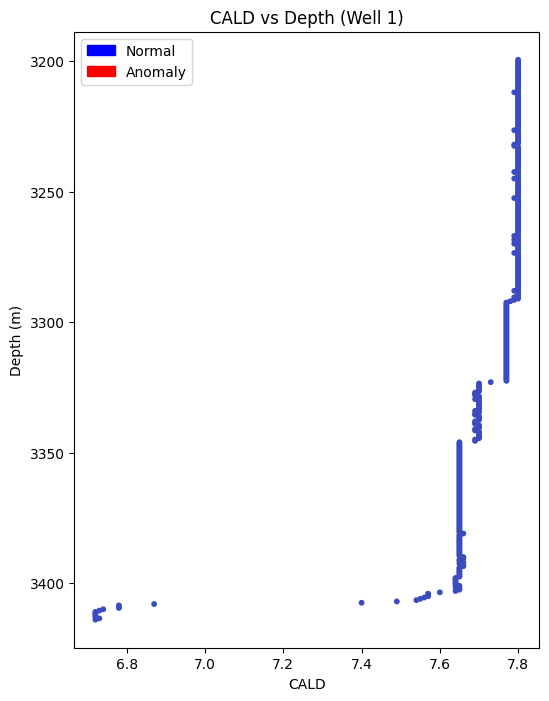

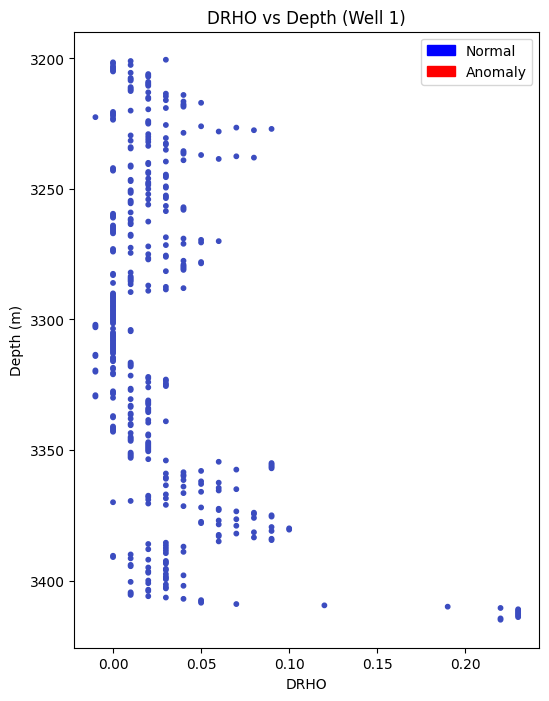

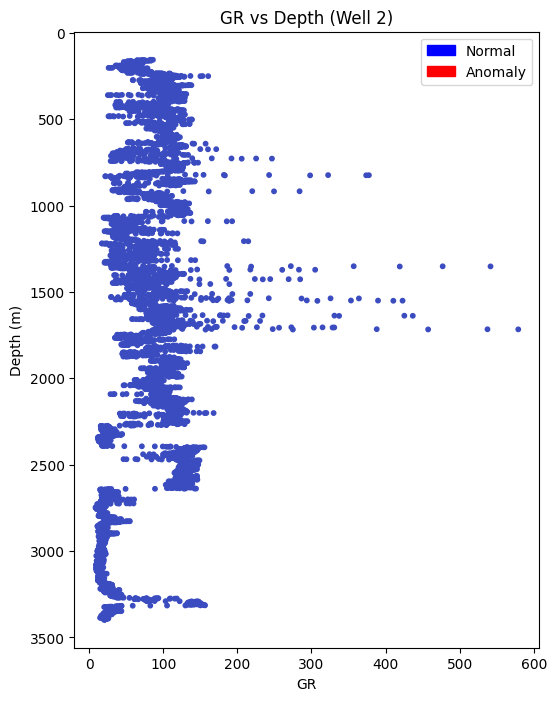

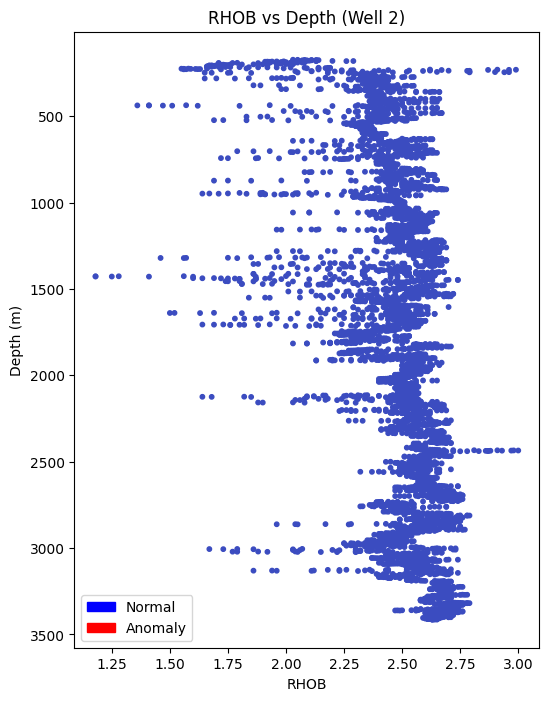

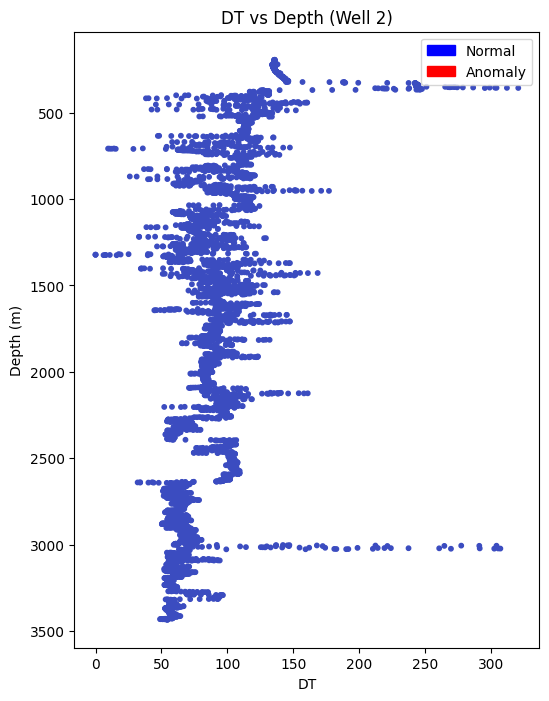

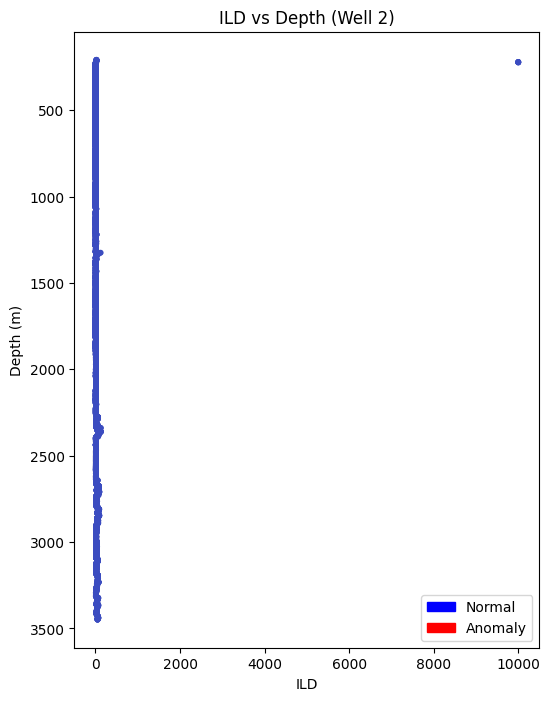

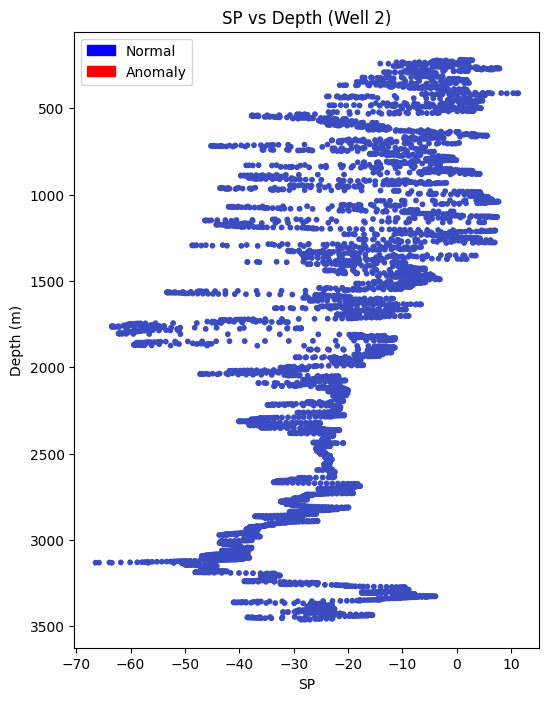

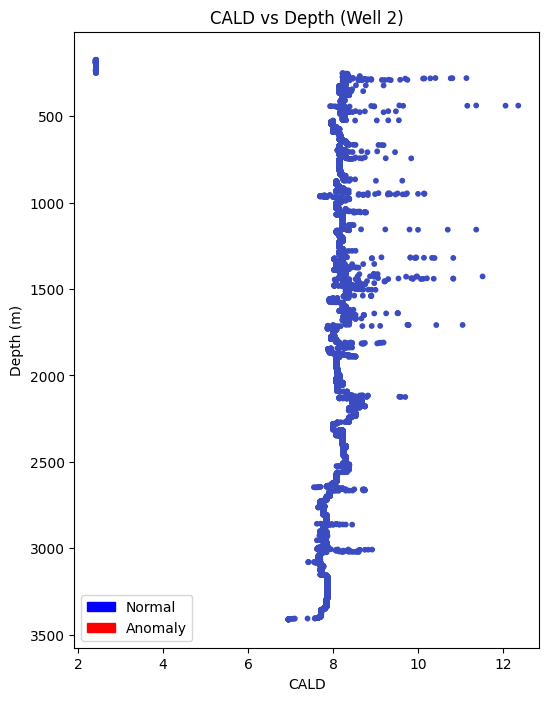

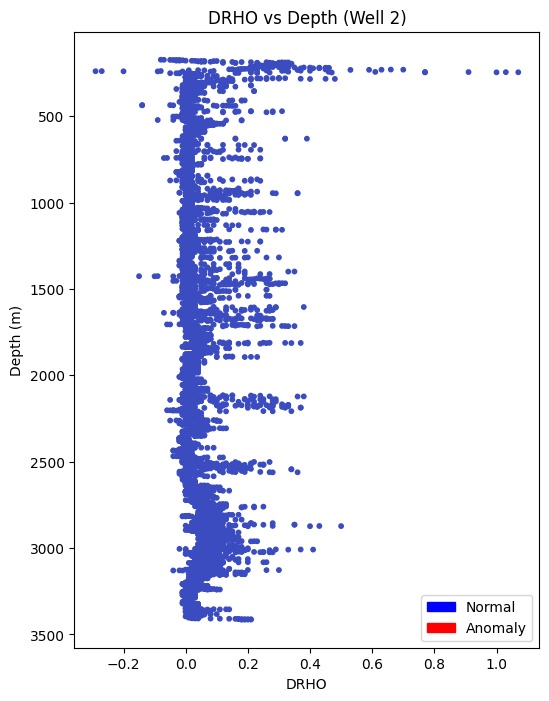

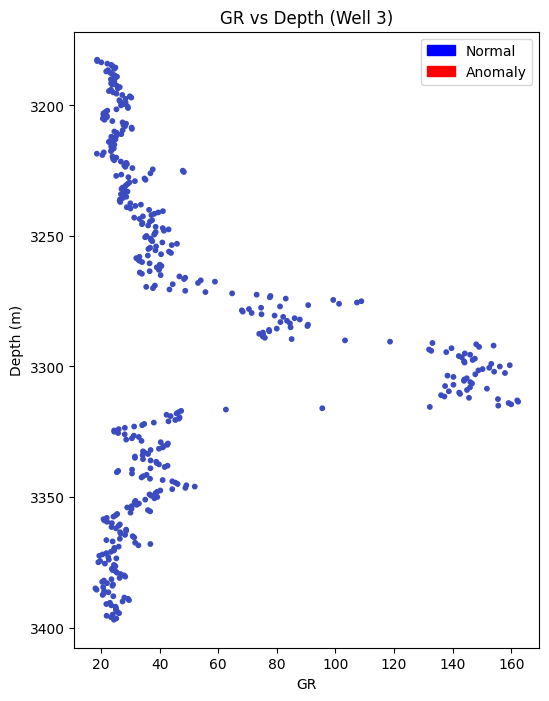

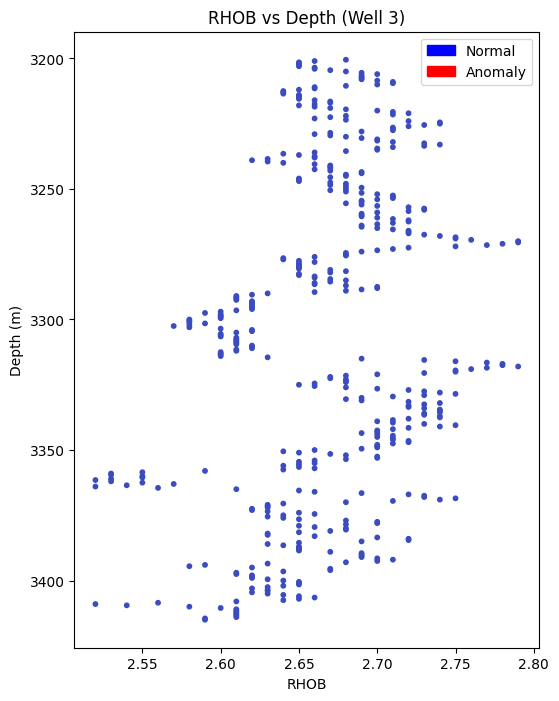

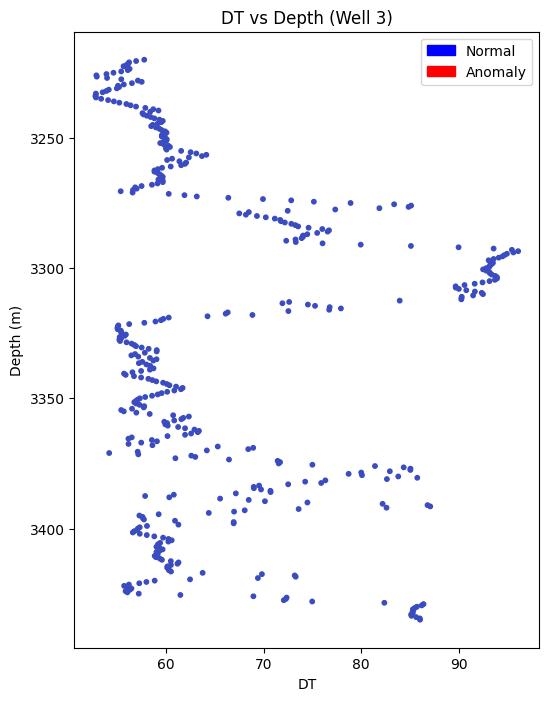

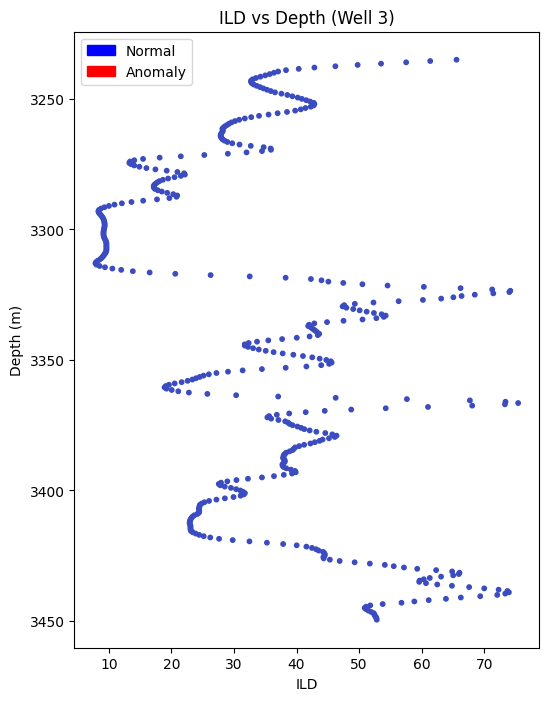

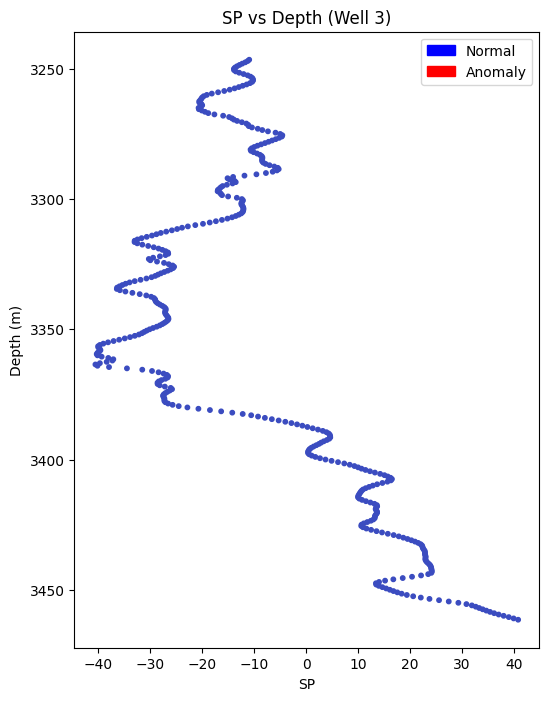

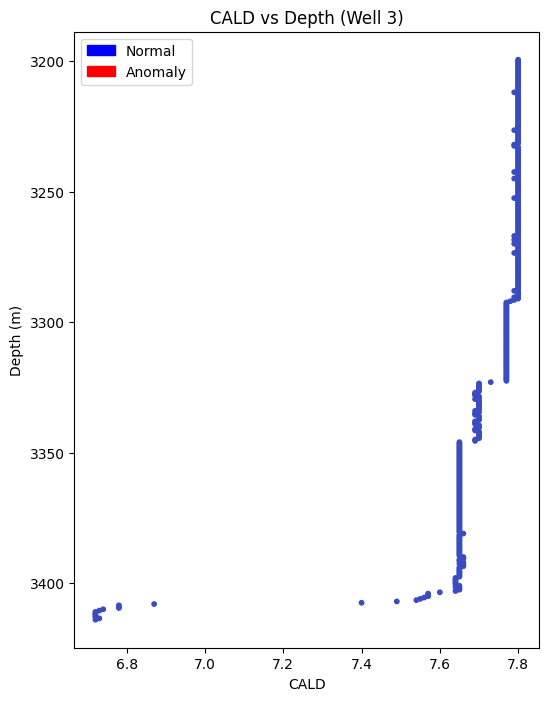

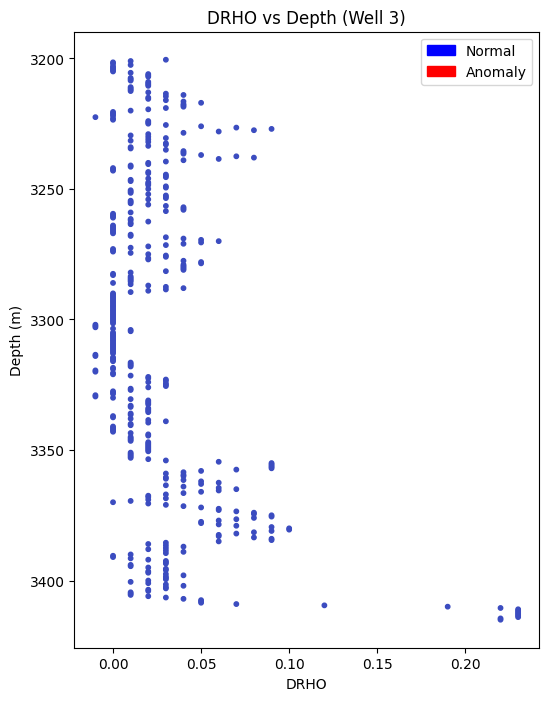

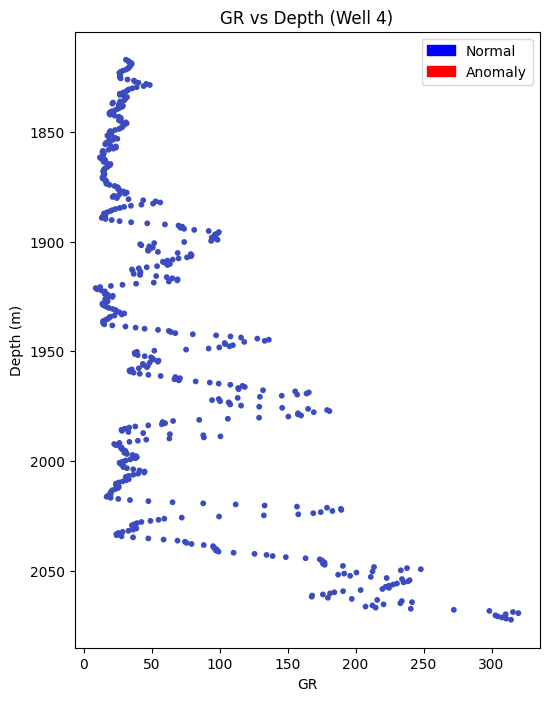

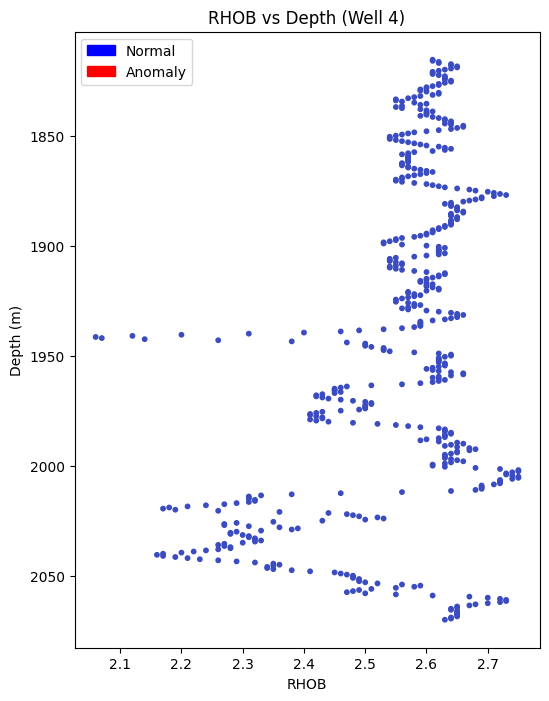

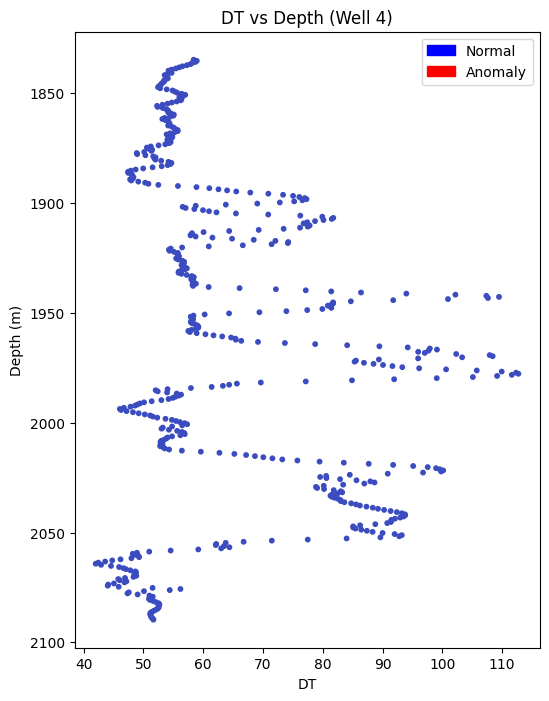

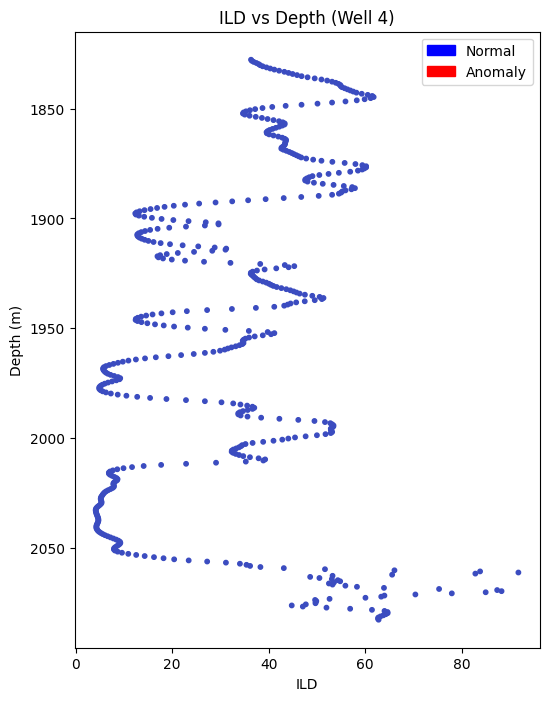

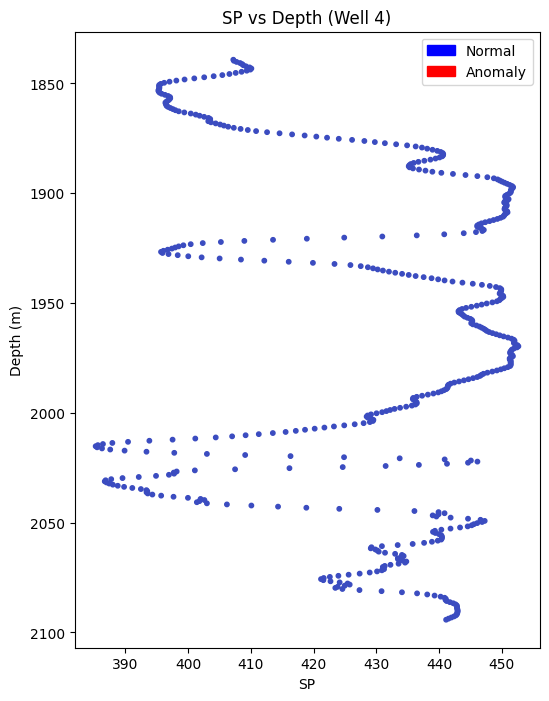

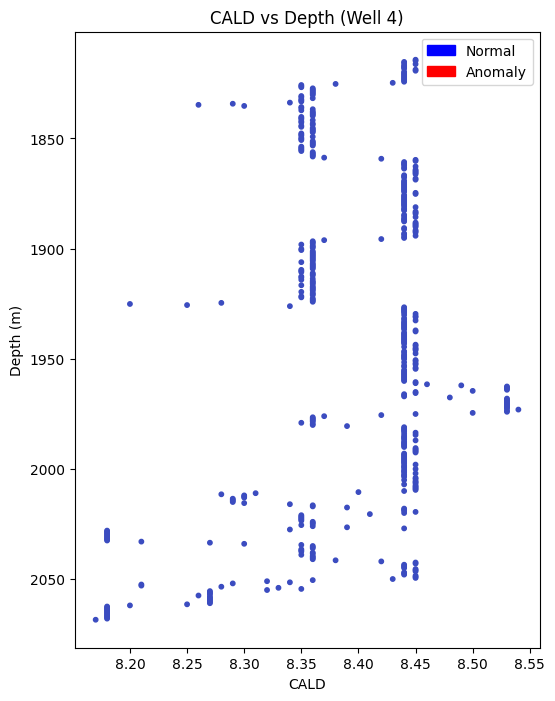

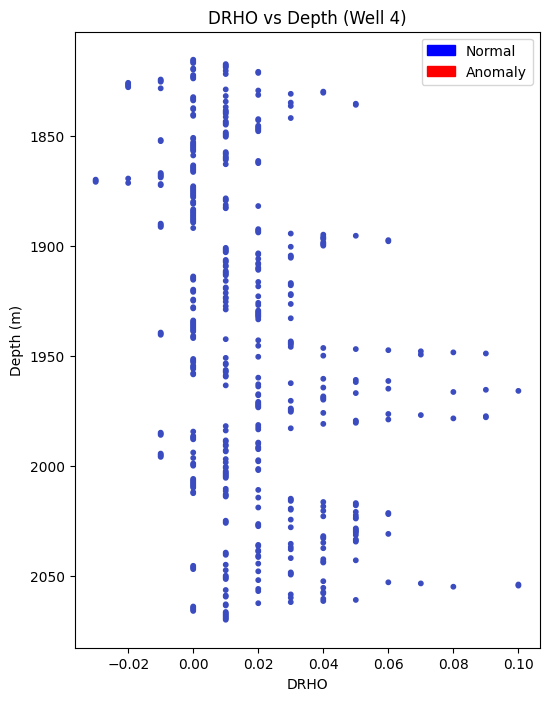

In [ ]:
# ==========================
# 1. Import Libraries
# ==========================
import os
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# ==========================
# 2. Define LAS file paths
# ==========================
las_files = {
    "Well 1": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 1.las",
    "Well 2": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 2.las",
    "Well 3": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 3.las",
    "Well 4": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 4.las",
}

# List of features to use
features = ['GR', 'RHOB', 'DT', 'ILD', 'SP', 'CALD', 'DRHO']

# ==========================
# 3. Load LAS files safely
# ==========================
wells = {}

for well_name, file_path in las_files.items():
    las = lasio.read(file_path)
    df = las.df()  # Load log curves
    
    # Reset index to get depth as a column
    df.reset_index(inplace=True)
    df.rename(columns={df.columns[0]: 'DEPT'}, inplace=True)
    
    # Select only available features
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"{well_name}: Warning, missing features ignored: {missing_features}")
    
    df_selected = df[['DEPT'] + available_features].copy()
    
    wells[well_name] = df_selected
    
    # Export to CSV
    csv_path = f"{well_name.replace(' ', '_')}_cleaned.csv"
    df_selected.to_csv(csv_path, index=False)
    print(f"{well_name} saved to {csv_path}")

# ==========================
# 4. Scale features
# ==========================
scalers = {}
wells_scaled = {}
for well_name, df in wells.items():
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df[available_features])
    wells_scaled[well_name] = pd.DataFrame(df_scaled, columns=available_features)
    scalers[well_name] = scaler

# ==========================
# 5. Build Autoencoder Model
# ==========================
input_dim = len(available_features)
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# ==========================
# 6. Train and detect anomalies
# ==========================
reconstruction_errors = {}
autoencoder_anomalies = {}
gr_threshold = 0.6  # Adjust threshold for GR

for well_name, df_scaled in wells_scaled.items():
    autoencoder.fit(df_scaled, df_scaled, epochs=50, batch_size=32, verbose=0)
    reconstructed = autoencoder.predict(df_scaled)
    
    errors = np.mean(np.square(df_scaled - reconstructed), axis=1)
    reconstruction_errors[well_name] = errors
    
    # Flag top 5% errors as anomalies
    error_threshold = np.percentile(errors, 95)
    autoencoder_anomalies[well_name] = errors > error_threshold

# ==========================
# 7. Plot features vs depth with anomalies and legend
# ==========================
for well_name, df in wells.items():
    df_scaled = wells_scaled[well_name]
    
    df['ANOMALY_STAT'] = df['GR'] > gr_threshold if 'GR' in df.columns else False
    df['ANOMALY_AE'] = autoencoder_anomalies[well_name]
    df['ANOMALY_FINAL'] = df['ANOMALY_STAT'] & df['ANOMALY_AE']
    
    for feature in available_features:
        plt.figure(figsize=(6, 8))
        scatter = plt.scatter(df[feature], df['DEPT'], c=df['ANOMALY_FINAL'], 
                              cmap='coolwarm', s=10)
        plt.gca().invert_yaxis()
        plt.title(f"{feature} vs Depth ({well_name})")
        plt.xlabel(feature)
        plt.ylabel("Depth (m)")
        
        # Add legend manually
        import matplotlib.patches as mpatches
        normal_patch = mpatches.Patch(color='blue', label='Normal')
        anomaly_patch = mpatches.Patch(color='red', label='Anomaly')
        plt.legend(handles=[normal_patch, anomaly_patch])
        
        plt.show()


In [ ]:
# Summary of anomalies per well
for well_name, df in wells.items():
    anomaly_count = df['ANOMALY_FINAL'].sum()
    total_count = df.shape[0]
    print(f"{well_name}: {anomaly_count} anomalies out of {total_count} samples ({(anomaly_count/total_count)*100:.2f}%)")
    

Well 1: 0 anomalies out of 567 samples (0.00%)
Well 2: 0 anomalies out of 6622 samples (0.00%)
Well 3: 0 anomalies out of 567 samples (0.00%)
Well 4: 0 anomalies out of 565 samples (0.00%)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Autoencoder Anomalies: 0 out of 565


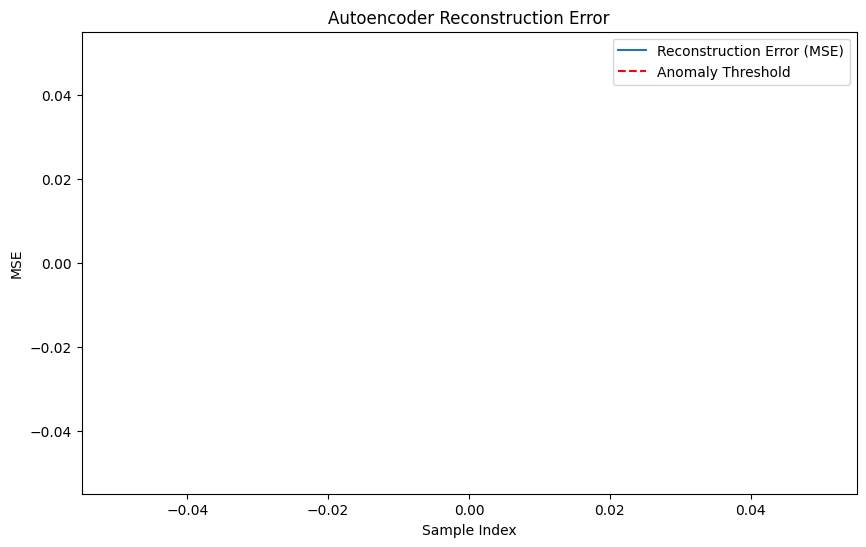

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

features = ['GR', 'RHOB', 'DT', 'ILD', 'SP', 'CALD', 'DRHO']
X = df[features].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Example: Combine both methods
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

input_dim = X_scaled.shape[1]

# Autoencoder architecture
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=Adam(), loss='mse')

# Train the autoencoder
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=32, verbose=0)

reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

# Set threshold: e.g., mean + 3*std
threshold = mse.mean() + 3 * mse.std()
autoencoder_anomalies = mse > threshold

# Add to dataframe
df['ANOMALY_AE'] = autoencoder_anomalies
print(f"Autoencoder Anomalies: {np.sum(autoencoder_anomalies)} out of {len(df)}")

# === Step 5: Visualize Anomalies ===
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(mse, label='Reconstruction Error (MSE)')
plt.axhline(y=threshold, color='r', linestyle='--', label='Anomaly Threshold')
plt.title('Autoencoder Reconstruction Error')
plt.xlabel('Sample Index')
plt.ylabel('MSE')
plt.legend()
plt.show()

# === Step 6: Save the Model ===
df['ANOMALY_FINAL'] = df['ANOMALY_STAT'] & df['ANOMALY_AE']
autoencoder.save('autoencoder_model.h5')
